# Architecture comparison: repeated-seed analysis

This notebook reads `results/results_TO_UPDATE.csv`, extracts validation metrics, audits the expected 8 architectures × 4 datasets × 5 seeds, and compares architectures with a statsmodels linear mixed-effects model (LMM).

The CSV includes repeated `dvmamba` APTOS entries and is missing some architecture/dataset/seed combinations. Repeated entries are resolved by keeping the latest timestamp per architecture, dataset, and seed. Missing cells are reported, never imputed. Feature-only `distill` rows are excluded because they do not contain classifier AUROC.

Primary response: validation AUROC. Fixed effects: architecture and dataset. Random variance components: seed and architecture-by-dataset cell. The full interaction as fixed effects is omitted because missing cells make its design matrix singular. With only five seed levels, treat seed variance and p-values as exploratory; emphasize the per-seed distributions and medians in paper figures.

In [8]:
from pathlib import Path
import json
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels
import statsmodels.formula.api as smf
from IPython.display import display

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "results").is_dir():
    PROJECT_ROOT = PROJECT_ROOT.parent

CSV_PATH = PROJECT_ROOT / "results" / "results_best_ckpt.csv"
FIGURE_DIR = PROJECT_ROOT / "images" / "paper_figures"

MODE_TO_ARCHITECTURE = {
    "mobilenet": "MobileNet",
    "efficientnet": "EfficientNet",
    "vmamba": "VMamba",
    "dvmamba": "VMamba_DIST",
    "unet": "UNet",
    "retfound_finetune": "RETFound",
    "tinyvit": "TinyVit",
    "dtinyvit": "TinyVit_DIST",
}
ARCHITECTURES = [
    "EfficientNet", "MobileNet", "RETFound", "TinyVit", "TinyVit_DIST",
    "UNet", "VMamba", "VMamba_DIST",
]
DATASETS = ["aptos", "idrid", "mbrset", "messidor"]
EXPECTED_SEEDS = ["42", "43", "44", "45", "46"]
METRIC_KEYS = {
    "val_auroc": "val/auroc",
    "val_f1": "val/f1",
    "val_accuracy": "val/acc",
    "val_aupr": "val/aupr",
}

sns.set_theme(style="whitegrid", context="paper", font_scale=1.05)
plt.rcParams.update({"figure.dpi": 130, "savefig.dpi": 300, "font.family": "DejaVu Sans"})

print(f"CSV: {CSV_PATH}")
print(f"statsmodels: {statsmodels.__version__}")
assert CSV_PATH.is_file(), f"Could not find {CSV_PATH}"

CSV: /home/andremitri/code/LEMUR/results/results_best_ckpt.csv
statsmodels: 0.15.0


In [9]:
def parse_metrics(value):
    if isinstance(value, dict):
        return value
    if not isinstance(value, str) or not value.strip():
        return {}
    try:
        parsed = json.loads(value)
    except json.JSONDecodeError:
        return {}
    return parsed if isinstance(parsed, dict) else {}


raw = pd.read_csv(CSV_PATH, dtype={"seed": "string"})
raw["timestamp"] = pd.to_numeric(raw["timestamp"], errors="coerce")
raw["architecture"] = raw["mode"].map(MODE_TO_ARCHITECTURE)

classifier = raw.loc[raw["architecture"].notna()].copy()
metric_dicts = classifier["val_metrics"].map(parse_metrics)
for column, key in METRIC_KEYS.items():
    classifier[column] = pd.to_numeric(metric_dicts.map(lambda metrics: metrics.get(key)), errors="coerce")

classifier["seed"] = classifier["seed"].str.strip()
classifier = classifier.dropna(subset=["dataset", "seed", "val_auroc"]).copy()
classifier["dataset"] = classifier["dataset"].str.lower()

print(f"CSV rows: {len(raw)}")
print(f"Classifier rows with validation AUROC: {len(classifier)}")
print(f"Feature-only/non-classification rows excluded: {len(raw) - len(classifier)}")
display(classifier.groupby(["mode", "dataset"], observed=True).size().rename("rows").reset_index())

CSV rows: 160
Classifier rows with validation AUROC: 160
Feature-only/non-classification rows excluded: 0


,mode,dataset,rows
0,dtinyvit,aptos,5
1,dtinyvit,idrid,5
2,dtinyvit,mbrset,5
3,dtinyvit,messidor,5
4,dvmamba,aptos,5
5,dvmamba,idrid,5
6,dvmamba,mbrset,5
7,dvmamba,messidor,5
8,efficientnet,aptos,5
9,efficientnet,idrid,5


## Coverage and repeated seeds

Repeated architecture/dataset/seed rows are counted below and resolved by the latest timestamp. Coverage is compared with the planned seed set 42–46. An absent cell means the CSV does not contain that run; it is not replaced or inferred.

In [10]:
CELL_KEYS = ["architecture", "dataset", "seed"]
repeat_counts = (
    classifier.groupby(CELL_KEYS, dropna=False)
    .size()
    .rename("records")
    .reset_index()
)
duplicates = repeat_counts.loc[repeat_counts["records"] > 1].sort_values(CELL_KEYS)
print(f"Repeated architecture/dataset/seed cells: {len(duplicates)}")
display(duplicates)

analysis = (
    classifier.sort_values(["timestamp", "id"], na_position="first")
    .drop_duplicates(CELL_KEYS, keep="last")
    .copy()
)
analysis["architecture"] = pd.Categorical(
    analysis["architecture"], categories=ARCHITECTURES, ordered=True
)
analysis["dataset"] = pd.Categorical(analysis["dataset"], categories=DATASETS, ordered=True)
analysis["seed"] = analysis["seed"].astype(str)
analysis["architecture_dataset"] = (
    analysis["architecture"].astype(str) + "__" + analysis["dataset"].astype(str)
)

expected = pd.MultiIndex.from_product(
    [ARCHITECTURES, DATASETS, EXPECTED_SEEDS], names=CELL_KEYS
).to_frame(index=False)
observed = analysis[CELL_KEYS].drop_duplicates()
coverage = expected.merge(observed, on=CELL_KEYS, how="left", indicator=True)
missing_runs = coverage.loc[coverage["_merge"] == "left_only", CELL_KEYS]
coverage_table = (
    analysis.groupby(["architecture", "dataset"], observed=False)
    .size()
    .unstack(fill_value=0)
    .reindex(index=ARCHITECTURES, columns=DATASETS, fill_value=0)
)

print(f"Rows before seed deduplication: {len(classifier)}")
print(f"Rows after seed deduplication: {len(analysis)}")
print(f"Expected runs: {len(expected)}; missing architecture/dataset/seed cells: {len(missing_runs)}")
display(coverage_table)
if not missing_runs.empty:
    display(missing_runs.sort_values(CELL_KEYS))

Repeated architecture/dataset/seed cells: 0


,architecture,dataset,seed,records


Rows before seed deduplication: 160
Rows after seed deduplication: 160
Expected runs: 160; missing architecture/dataset/seed cells: 0


dataset,aptos,idrid,mbrset,messidor
architecture,,,,
EfficientNet,5,5,5,5
MobileNet,5,5,5,5
RETFound,5,5,5,5
TinyVit,5,5,5,5
TinyVit_DIST,5,5,5,5
UNet,5,5,5,5
VMamba,5,5,5,5
VMamba_DIST,5,5,5,5


## Descriptive summaries and paper figures

The first figure shows median AUROC by architecture and dataset, annotated with the number of available seeds. The second shows individual seed values overlaid on boxplots. Both are descriptive; missing seed runs remain visible as smaller sample counts.

,dataset,architecture,median,q1,q3,n
0,aptos,EfficientNet,0.927107,0.926800,0.927638,5
1,aptos,MobileNet,0.929489,0.925406,0.934535,5
2,aptos,RETFound,0.931068,0.929984,0.933801,5
3,aptos,TinyVit,0.926222,0.922381,0.933262,5
4,aptos,TinyVit_DIST,0.939666,0.935618,0.947432,5
5,aptos,UNet,0.939568,0.938434,0.940015,5
6,aptos,VMamba,0.829928,0.737781,0.847946,5
7,aptos,VMamba_DIST,0.869760,0.868373,0.873043,5
8,idrid,EfficientNet,0.601044,0.580286,0.602294,5
9,idrid,MobileNet,0.585985,0.566730,0.586812,5


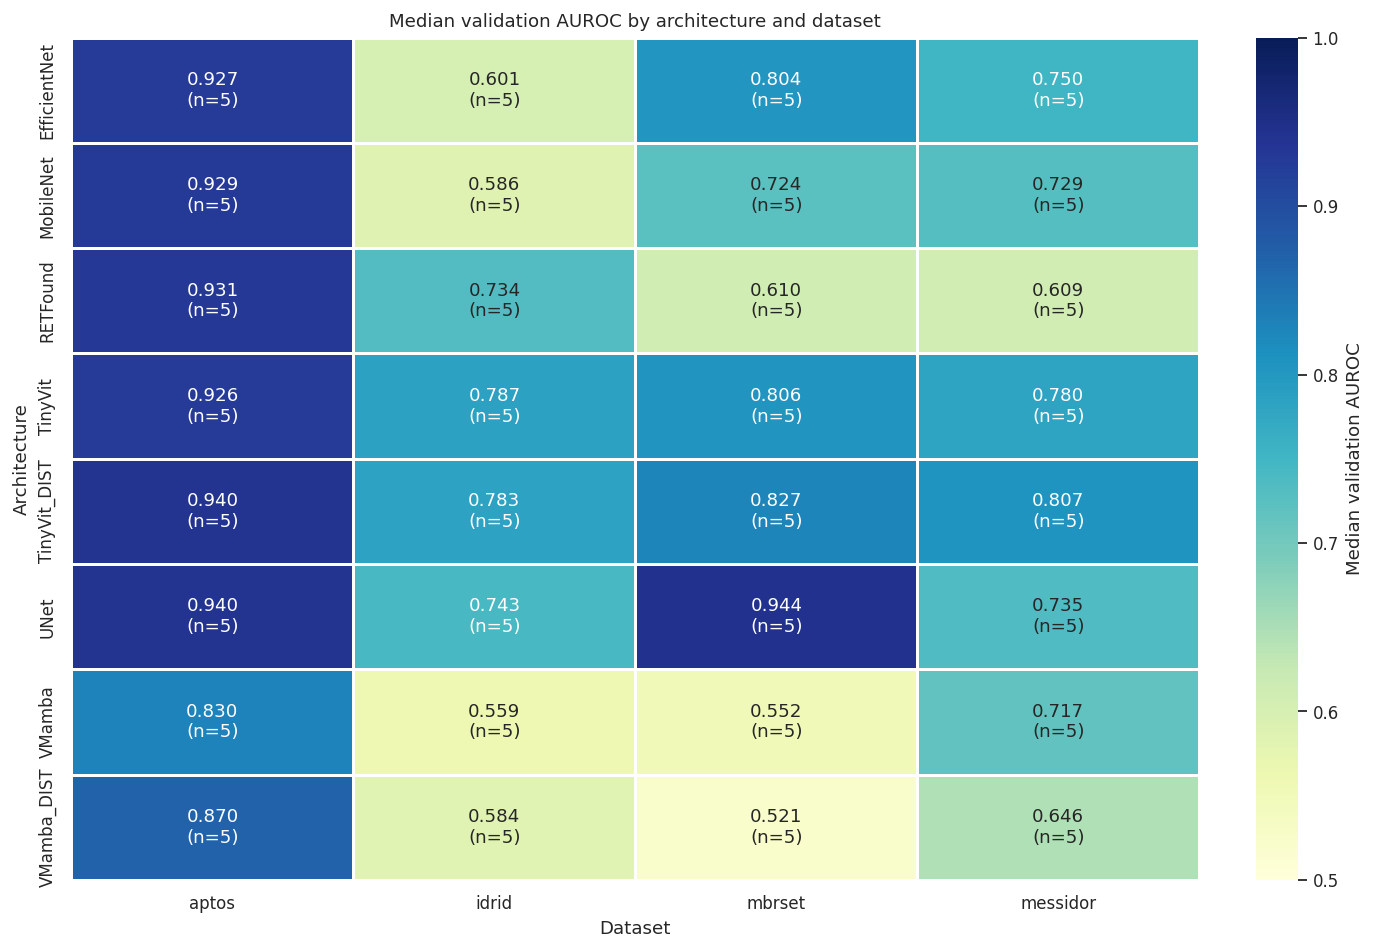

In [11]:
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

summary_auroc = (
    analysis.groupby(["dataset", "architecture"], observed=True)["val_auroc"]
    .agg(median="median", q1=lambda values: values.quantile(0.25), q3=lambda values: values.quantile(0.75), n="count")
    .reset_index()
)
display(summary_auroc.sort_values(["dataset", "architecture"]))

median_matrix = summary_auroc.pivot(index="architecture", columns="dataset", values="median")
n_matrix = summary_auroc.pivot(index="architecture", columns="dataset", values="n")
median_matrix = median_matrix.reindex(index=ARCHITECTURES, columns=DATASETS)
n_matrix = n_matrix.reindex(index=ARCHITECTURES, columns=DATASETS)
annotations = median_matrix.copy().astype(object)
for architecture in ARCHITECTURES:
    for dataset in DATASETS:
        median = median_matrix.loc[architecture, dataset]
        count = n_matrix.loc[architecture, dataset]
        annotations.loc[architecture, dataset] = "" if pd.isna(median) else f"{median:.3f}\n(n={int(count)})"

fig, ax = plt.subplots(figsize=(10.5, 7.2), constrained_layout=True)
sns.heatmap(
    median_matrix.astype(float),
    annot=annotations,
    fmt="",
    cmap="YlGnBu",
    vmin=0.50,
    vmax=1.00,
    linewidths=0.7,
    linecolor="white",
    cbar_kws={"label": "Median validation AUROC"},
    ax=ax,
)
ax.set(title="Median validation AUROC by architecture and dataset", xlabel="Dataset", ylabel="Architecture")
fig.savefig(FIGURE_DIR / "auroc_median_heatmap.png", bbox_inches="tight")
plt.show()

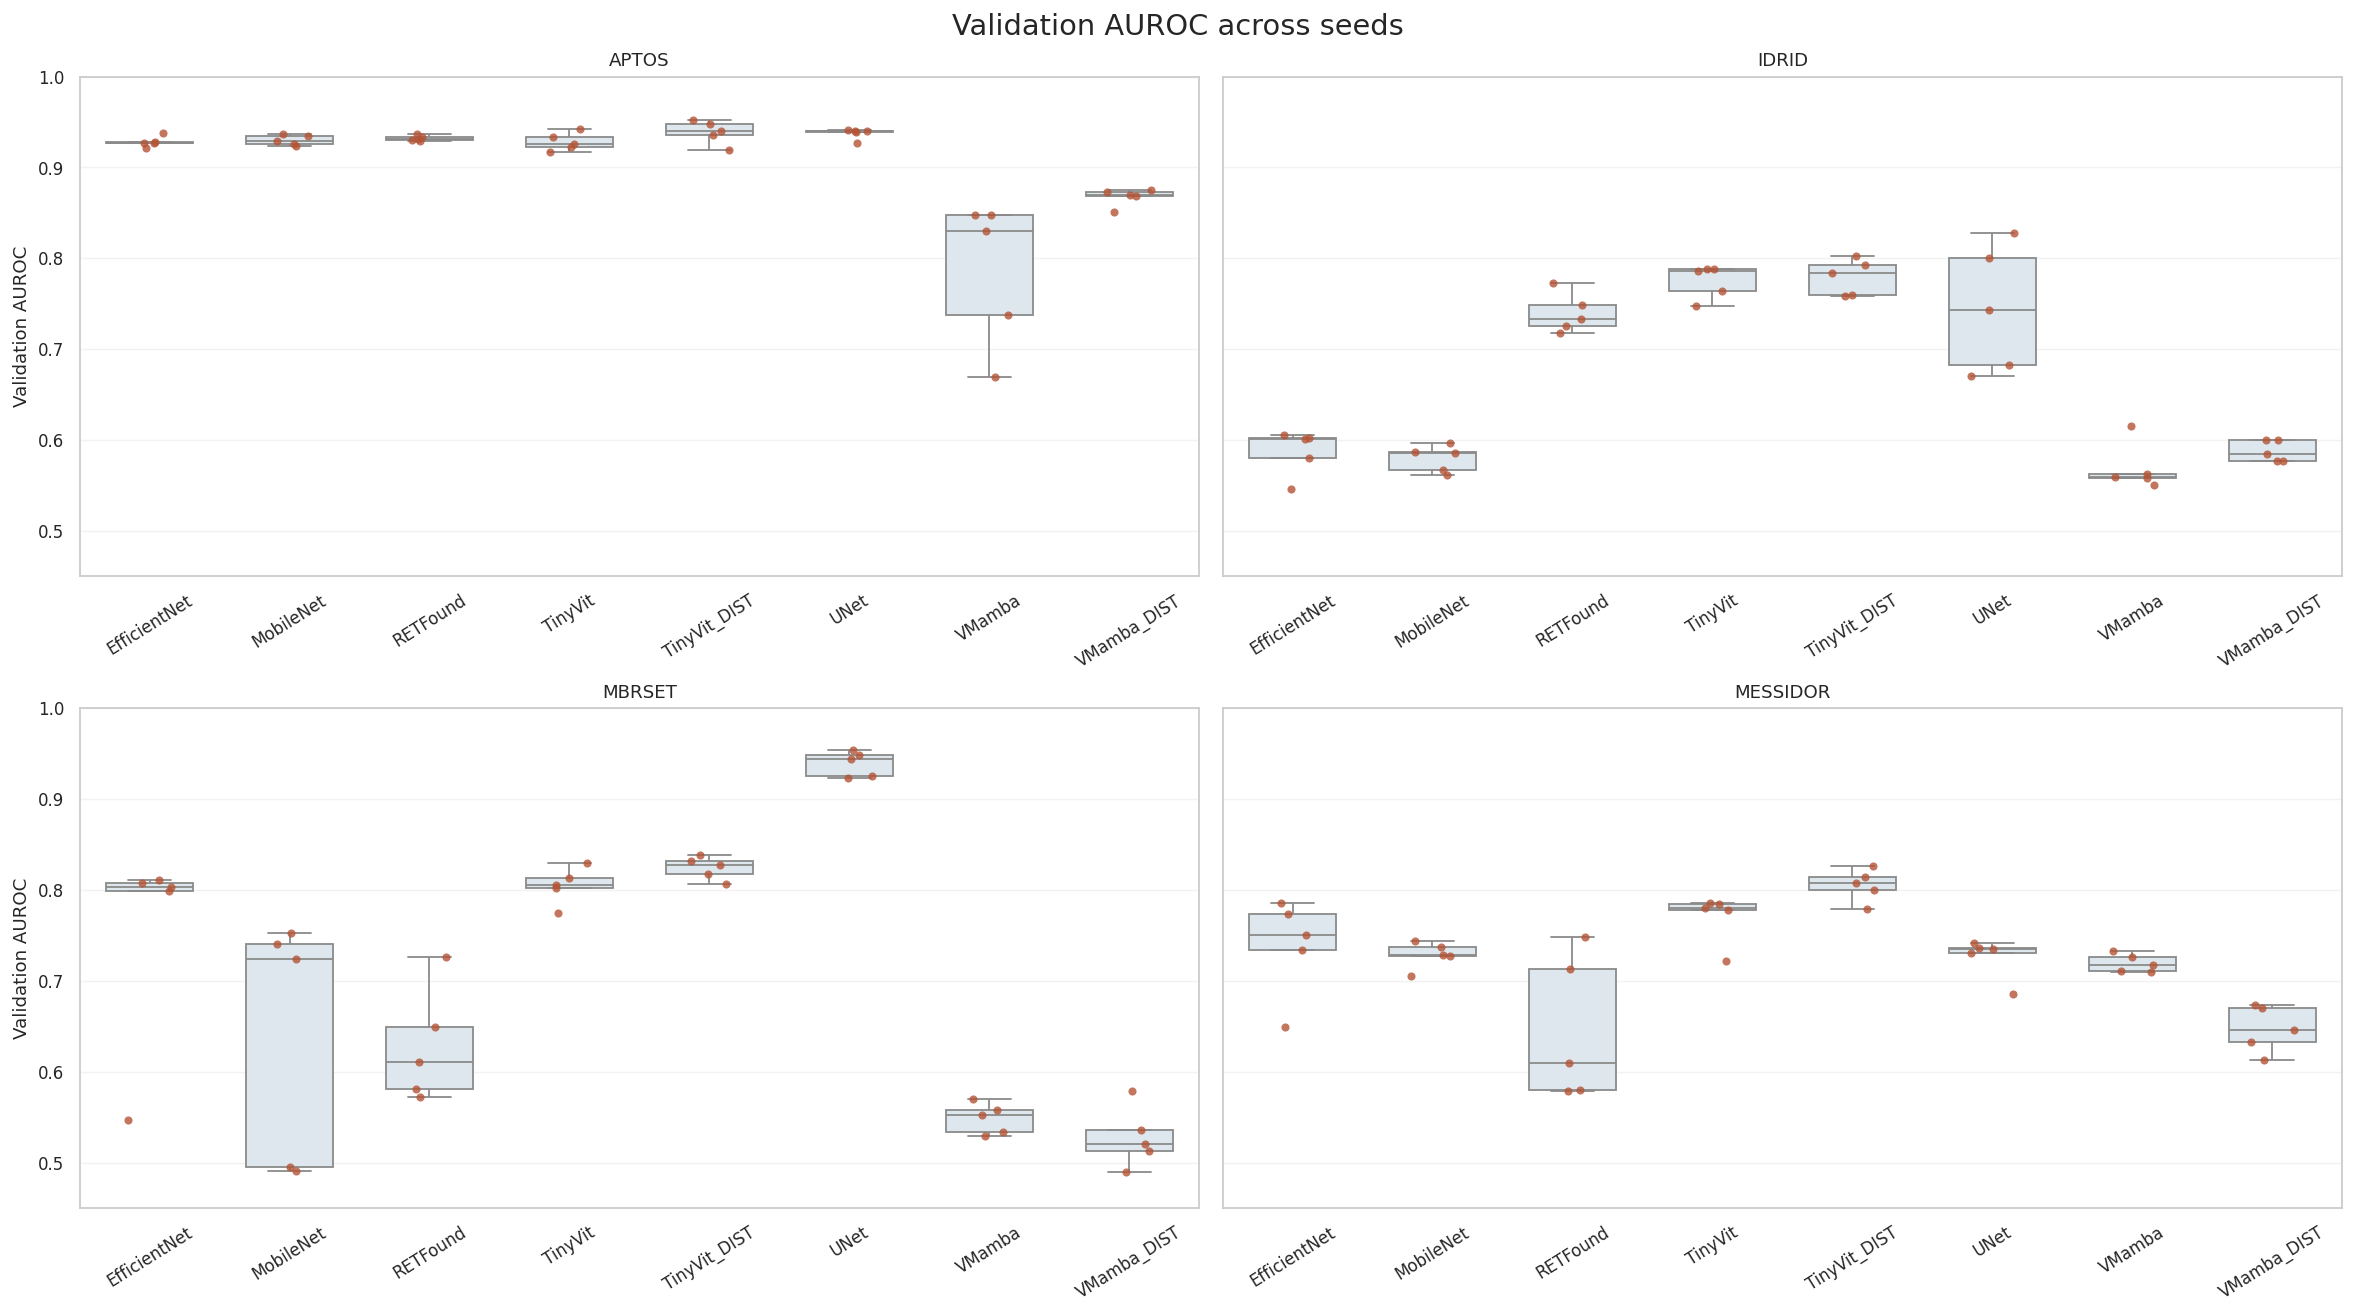

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(18, 10), sharey=True, constrained_layout=True)
for ax, dataset in zip(axes.flat, DATASETS):
    subset = analysis.loc[analysis["dataset"].astype(str) == dataset]
    sns.boxplot(
        data=subset,
        x="architecture",
        y="val_auroc",
        order=ARCHITECTURES,
        color="#dce8ef",
        showfliers=False,
        width=0.62,
        ax=ax,
    )
    sns.stripplot(
        data=subset,
        x="architecture",
        y="val_auroc",
        order=ARCHITECTURES,
        color="#b45435",
        jitter=0.16,
        size=4.5,
        alpha=0.8,
        ax=ax,
    )
    ax.set_title(dataset.upper())
    ax.set_xlabel("")
    ax.set_ylabel("Validation AUROC")
    ax.set_ylim(0.45, 1.00)
    ax.tick_params(axis="x", labelrotation=32)
    ax.grid(axis="y", alpha=0.25)

fig.suptitle("Validation AUROC across seeds", fontsize=16)
fig.savefig(FIGURE_DIR / "auroc_seed_distributions.png", bbox_inches="tight")
plt.show()

## Linear mixed-effects model

The primary model is `validation AUROC ~ architecture + dataset`, with crossed random-intercept variance components for seed and architecture–dataset cell. This adjusts architecture comparisons for dataset difficulty, accounts for shared seed variation and cell-level deviations, and avoids the non-identifiable full architecture×dataset fixed interaction in the incomplete design.

Architecture and dataset coefficients are relative to EfficientNet and APTOS, respectively. The model uses REML. The five seed levels are few, and one variance component may be estimated near zero; report the design limitation alongside any inferential claims.

In [13]:
model_data = analysis.copy()
model_data["all_observations"] = 1
formula = "val_auroc ~ C(architecture) + C(dataset)"

lmm = smf.mixedlm(
    formula,
    data=model_data,
    groups=model_data["all_observations"],
    vc_formula={
        "seed": "0 + C(seed)",
        "architecture_dataset": "0 + C(architecture_dataset)",
    },
)
lmm_result = lmm.fit(reml=True, method="lbfgs", maxiter=1000, disp=False)

print(f"Formula: {formula}")
print(f"Converged: {lmm_result.converged}")
print(f"Observations: {int(lmm_result.nobs)}; seeds: {model_data['seed'].nunique()}")
print("Variance components:", dict(zip(lmm_result.model.exog_vc.names, lmm_result.vcomp)))
print(lmm_result.summary())

fixed_names = lmm_result.fe_params.index
fixed_ci = lmm_result.conf_int().loc[fixed_names]
fixed_effects = pd.DataFrame({
    "term": fixed_names,
    "estimate": lmm_result.fe_params.values,
    "std_error": lmm_result.bse_fe.values,
    "p_value": lmm_result.pvalues.loc[fixed_names].values,
    "ci_low": fixed_ci.iloc[:, 0].values,
    "ci_high": fixed_ci.iloc[:, 1].values,
})
display(fixed_effects)

Formula: val_auroc ~ C(architecture) + C(dataset)
Converged: False
Observations: 160; seeds: 5
Variance components: {'architecture_dataset': np.float64(0.0037164102311404456), 'seed': np.float64(0.00021926062686177547)}
                  Mixed Linear Model Regression Results
Model:                   MixedLM       Dependent Variable:       val_auroc
No. Observations:        160           Method:                   REML     
No. Groups:              1             Scale:                    0.0020   
Min. group size:         160           Log-Likelihood:           208.6075 
Max. group size:         160           Converged:                No       
Mean group size:         160.0                                            
--------------------------------------------------------------------------
                                Coef.  Std.Err.   z    P>|z| [0.025 0.975]
--------------------------------------------------------------------------
Intercept                        0.906    0.038 2

/home/andremitri/miniconda3/envs/mae/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2384: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  rslt = super().fit(
/tmp/ipykernel_117192/373836320.py:14: ConvergenceWarning: MixedLM optimization failed, trying a different optimizer may help.
  lmm_result = lmm.fit(reml=True, method="lbfgs", maxiter=1000, disp=False)
/tmp/ipykernel_117192/373836320.py:14: ConvergenceWarning: Gradient optimization failed, |grad| = 5.756725
  lmm_result = lmm.fit(reml=True, method="lbfgs", maxiter=1000, disp=False)
/tmp/ipykernel_117192/373836320.py:14: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  lmm_result = lmm.fit(reml=True, method="lbfgs", maxiter=1000, disp=False)
/tmp/ipykernel_117192/373836320.py:14: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  lmm_result = lmm.fit(reml=True, method="lbfgs", maxiter

,term,estimate,std_error,p_value,ci_low,ci_high
0,Intercept,0.906006,0.038157,1.264609e-124,0.831219,0.980792
1,C(architecture)[T.MobileNet],-0.032162,0.045321,4.779199e-01,-0.120989,0.056665
2,C(architecture)[T.RETFound],-0.015420,0.045321,7.336682e-01,-0.104248,0.073407
3,C(architecture)[T.TinyVit],0.067792,0.045321,1.347026e-01,-0.021036,0.156619
4,C(architecture)[T.TinyVit_DIST],0.085095,0.045321,6.043389e-02,-0.003732,0.173922
5,C(architecture)[T.UNet],0.084912,0.045321,6.098874e-02,-0.003915,0.173739
6,C(architecture)[T.VMamba],-0.095792,0.045321,3.454688e-02,-0.184619,-0.006964
7,C(architecture)[T.VMamba_DIST],-0.094271,0.045321,3.751768e-02,-0.183099,-0.005444
8,C(dataset)[T.idrid],-0.235750,0.032047,1.888742e-13,-0.298560,-0.172939
9,C(dataset)[T.mbrset],-0.197689,0.032047,6.881403e-10,-0.260500,-0.134879


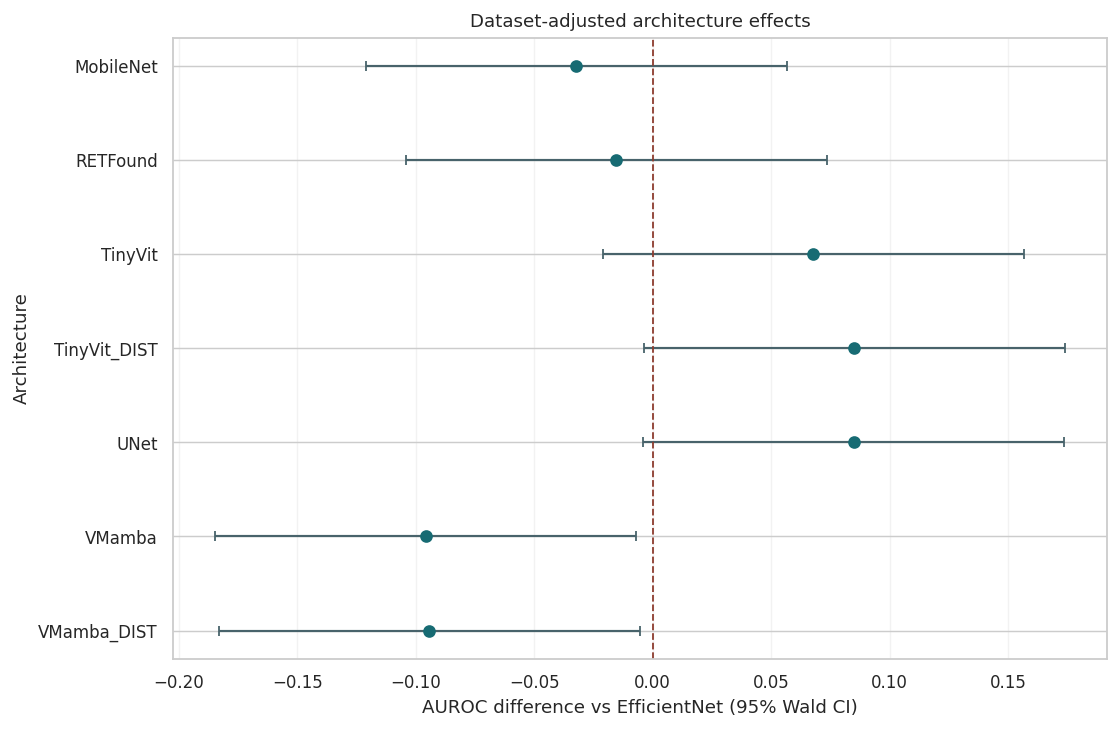

In [14]:
architecture_terms = fixed_effects.loc[fixed_effects["term"].str.startswith("C(architecture)")].copy()
architecture_terms["architecture"] = architecture_terms["term"].str.extract(r"\[T\.(.+)\]$")[0]
architecture_terms = architecture_terms.set_index("architecture").reindex(ARCHITECTURES[1:]).dropna(subset=["estimate"])

fig, ax = plt.subplots(figsize=(8.5, 5.5), constrained_layout=True)
y = np.arange(len(architecture_terms))
xerr = np.vstack([
    architecture_terms["estimate"] - architecture_terms["ci_low"],
    architecture_terms["ci_high"] - architecture_terms["estimate"],
])
ax.errorbar(
    architecture_terms["estimate"],
    y,
    xerr=xerr,
    fmt="o",
    color="#176b73",
    ecolor="#48636b",
    capsize=3,
    markersize=6,
)
ax.axvline(0, color="#8d3c2f", linestyle="--", linewidth=1)
ax.set_yticks(y, architecture_terms.index)
ax.invert_yaxis()
ax.set_xlabel("AUROC difference vs EfficientNet (95% Wald CI)")
ax.set_ylabel("Architecture")
ax.set_title("Dataset-adjusted architecture effects")
ax.grid(axis="x", alpha=0.25)
fig.savefig(FIGURE_DIR / "lmm_architecture_effects_auroc.png", bbox_inches="tight")
plt.show()

In [15]:
import pandas as pd
from labicompare.core.data import EvaluationData
from labicompare.stats import wilcoxon_holm
from labicompare.plots.ranking import plot_cd_diagram

# 1. Prepare your data (Rows = Datasets, Columns = Models)
# Data extracted automatically from results_best_ckpt.csv (Mean F1-Scores)
data_dict = {
    'EfficientNet': [0.6192, 0.1887, 0.4714, 0.4055],
    'LEMUR':        [0.4447, 0.2549, 0.1804, 0.1837],
    'MobileNet':    [0.6473, 0.1677, 0.3606, 0.3309],
    'RETFound':     [0.7033, 0.4402, 0.2716, 0.2987],
    'TinyVit':      [0.6194, 0.3481, 0.4760, 0.4094],
    'TinyVit-D':    [0.7358, 0.4707, 0.5703, 0.5517],
    'UNet':         [0.6442, 0.3338, 0.6926, 0.3154],
    'VMamba':       [0.2960, 0.2033, 0.1768, 0.3223]
}

# Assign the row indices to your specific datasets
df = pd.DataFrame(data_dict, index=['APTOS', 'IDRiD', 'mBRSET', 'MESSIDOR'])

# 2. Wrap the data (F1-Score: higher_is_better=True)
eval_data = EvaluationData(df, higher_is_better=True)

# 3. Run the statistical tests (Friedman + Wilcoxon-Holm)
summary = wilcoxon_holm(eval_data, alpha=0.05)
print(summary)

# 4. Generate the Critical Difference Diagram (CD Diagram)
fig = plot_cd_diagram(
    data=eval_data,
    summary=summary,
    title="Model Comparison (F1-Score across 4 Datasets)",
    highlight_models=['LEMUR'],
    highlight_color='#d97706'
)

# Save the plot
fig.savefig("cd_diagram_f1.png", dpi=300, bbox_inches='tight')
print("Plot successfully saved as cd_diagram_f1.png")

ModuleNotFoundError: No module named 'labicompare'